In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
import pandas as pd

params = {'figure.figsize': (10, 10*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)

In [23]:
df = pd.read_hdf('../../dataset_complete/BDT/BDT_all.h5', key='data')

beta1 = df['ang_mean']#['Beta1Reco']

energy = df['RecoEnergy'][~np.isnan(beta1)]
label = df['Label'][~np.isnan(beta1)]
beta1 = df['ang_median'][~np.isnan(beta1)]

boolCC = (label == 1)
boolNC = (label == 0)

beta1_CC = beta1[boolCC]
beta1_NC = beta1[boolNC] 

(array([0.00361483, 0.00705246, 0.00903707, 0.01279366, 0.01711728,
        0.02122826, 0.02455958, 0.03083237, 0.03359665, 0.04139334,
        0.04674471, 0.05000514, 0.05535651, 0.05918397, 0.06758314,
        0.06900072, 0.07495455, 0.08151086, 0.08399163, 0.08927211,
        0.09405645, 0.09862814, 0.10521989, 0.10653115, 0.1119534 ,
        0.11390257, 0.12091959, 0.1200336 , 0.12666079, 0.13172864,
        0.13828495, 0.14501845, 0.1489168 , 0.15472888, 0.15809563,
        0.16879836, 0.17025138, 0.17886318, 0.18556125, 0.19562607,
        0.20625792, 0.2134167 , 0.22082356, 0.23184524, 0.24719055,
        0.25215208, 0.25881471, 0.27731413, 0.28808774, 0.30364568,
        0.32831158, 0.33224536, 0.352375  , 0.37147689, 0.39458345,
        0.40564058, 0.43473641, 0.45242072, 0.48038249, 0.50079565,
        0.53584532, 0.56306286, 0.59435594, 0.62575534, 0.66665253,
        0.69734314, 0.73171946, 0.77846417, 0.81510862, 0.86621238,
        0.91398484, 0.96140289, 1.01459759, 1.06

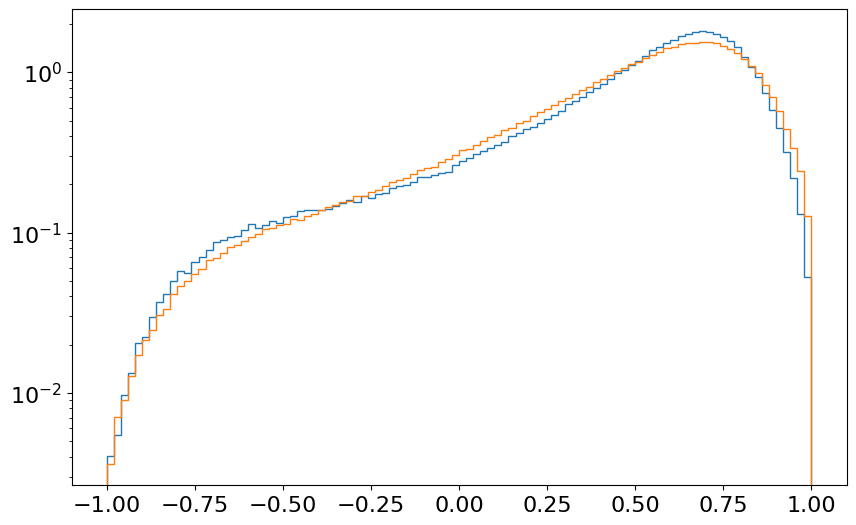

In [24]:
plt.hist(beta1[boolCC], bins=100, histtype='step', density=True, log=True)
plt.hist(beta1[boolNC], bins=100, histtype='step', density=True, log=True)

In [33]:
fpr = []
tpr = []

y_true = label
y_prob = beta1

uthreshold = 0.9#0.001#0.0002#0.77#0.75#0.0002#0.002
lthreshold = 0.5#0.62#0.60#0.0


#if count % 100 == 0:
    #print(count)
#count += 1

#y_pred = np.where((y_prob <= threshold), 1, 0)
y_pred = np.where((y_prob <= uthreshold)&(y_prob >= lthreshold), 1, 0)
                  
fp = np.sum((y_pred == 1) & (y_true == 0))
tp = np.sum((y_pred == 1) & (y_true == 1))

fn = np.sum((y_pred == 0) & (y_true == 1))
tn = np.sum((y_pred == 0) & (y_true == 0))

fpr.append(fp / (fp + tn))
tpr.append(tp / (tp + fn))


fpr = np.array(fpr)
tpr = np.array(tpr)

# Sort by FPR in case they're not
sorted_indices = np.argsort(fpr)
fpr = fpr[sorted_indices]
tpr = tpr[sorted_indices]

# Compute AUC using trapezoidal rule
auc = np.trapz(tpr, fpr)
print(f"AUC = {auc:.2f}")

AUC = 0.00


In [34]:
beta1[(beta1>=lthreshold)&(beta1<=uthreshold)]

0          0.665653
3          0.610043
4          0.897202
5          0.815956
6          0.621091
             ...   
1867977    0.563798
1867978    0.698100
1867981    0.623646
1867982    0.722645
1867985    0.551764
Name: ang_median, Length: 994690, dtype: float64

In [35]:
label[(beta1>=lthreshold)&(beta1<=uthreshold)][label == 0]

0          0.0
4          0.0
6          0.0
10         0.0
11         0.0
          ... 
1867977    0.0
1867978    0.0
1867981    0.0
1867982    0.0
1867985    0.0
Name: Label, Length: 736735, dtype: float64

(array([5.74065e+05, 4.33335e+05, 2.36441e+05, 1.63557e+05, 1.15172e+05,
        8.14930e+04, 5.86840e+04, 4.26400e+04, 3.13660e+04, 2.36200e+04,
        1.80680e+04, 1.40860e+04, 1.13950e+04, 9.04900e+03, 7.40000e+03,
        6.07000e+03, 5.10100e+03, 4.29800e+03, 3.68300e+03, 3.09200e+03,
        2.75100e+03, 2.44700e+03, 2.19000e+03, 1.98100e+03, 1.80500e+03,
        1.51600e+03, 1.40000e+03, 1.28000e+03, 1.14800e+03, 1.10000e+03,
        8.98000e+02, 7.94000e+02, 6.72000e+02, 6.69000e+02, 5.65000e+02,
        4.99000e+02, 4.60000e+02, 4.22000e+02, 3.54000e+02, 3.13000e+02,
        2.85000e+02, 2.76000e+02, 2.46000e+02, 2.21000e+02, 2.00000e+02,
        1.49000e+02, 1.50000e+02, 1.15000e+02, 9.90000e+01, 7.00000e+01,
        6.60000e+01, 4.70000e+01, 4.10000e+01, 3.30000e+01, 2.40000e+01,
        2.10000e+01, 1.30000e+01, 1.30000e+01, 9.00000e+00, 6.00000e+00,
        1.00000e+00, 7.00000e+00, 2.00000e+00, 2.00000e+00, 5.00000e+00,
        1.00000e+00, 1.00000e+00, 0.00000e+00, 0.00

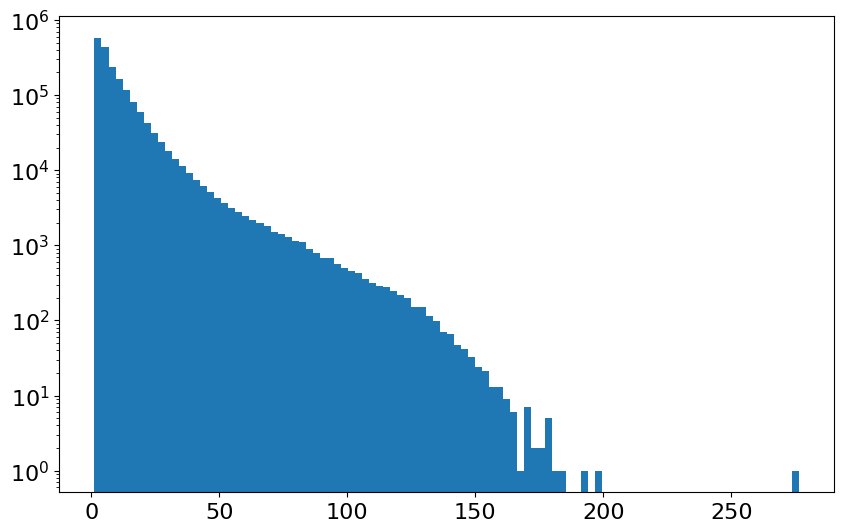

In [36]:
plt.hist(energy, bins=100, log=True)

Text(0, 0.5, 'True Positive Rate')

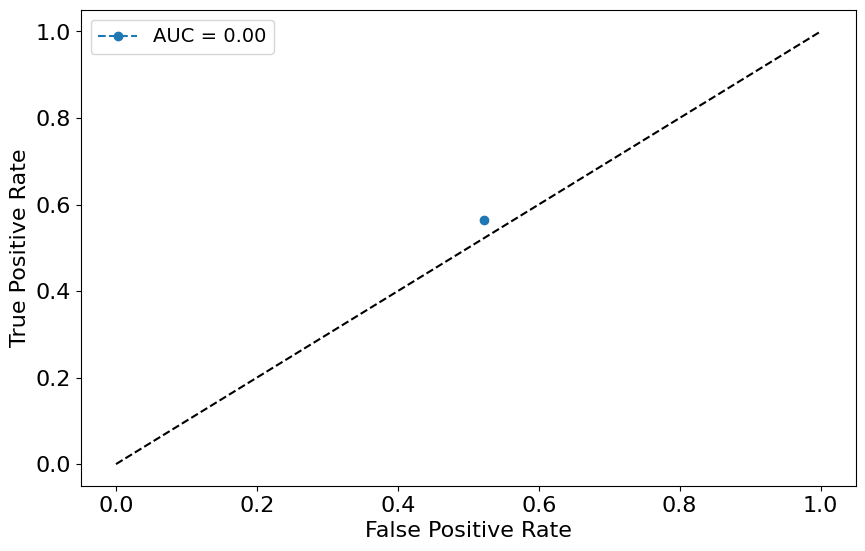

In [37]:
plt.plot(fpr, tpr, 'o--', label = f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

In [38]:
precision = []
recall = []

y_true = label
y_prob = beta1

    
#y_pred = np.where((y_prob <= threshold), 1, 0)
y_pred = np.where((y_prob <= uthreshold)&(y_prob >= lthreshold), 1, 0)
                  
fp = np.sum((y_pred == 1) & (y_true == 0))
tp = np.sum((y_pred == 1) & (y_true == 1))

fn = np.sum((y_pred == 0) & (y_true == 1))
tn = np.sum((y_pred == 0) & (y_true == 0))

precision.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)
recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)

baseline = len(beta1_CC)/(len(beta1_CC) + len(beta1_NC))
print(baseline)

precision = np.array(precision)
recall = np.array(recall)

# Sort by FPR in case they're not
sorted_indices = np.argsort(recall)
precision = precision[sorted_indices]
recall = recall[sorted_indices]

# Compute AUC using trapezoidal rule
auc_pr = np.trapz(precision, recall)
print(f"AUC = {auc:.2f}")

0.2446861189998849
AUC = 0.00


Text(0, 0.5, 'Precision')

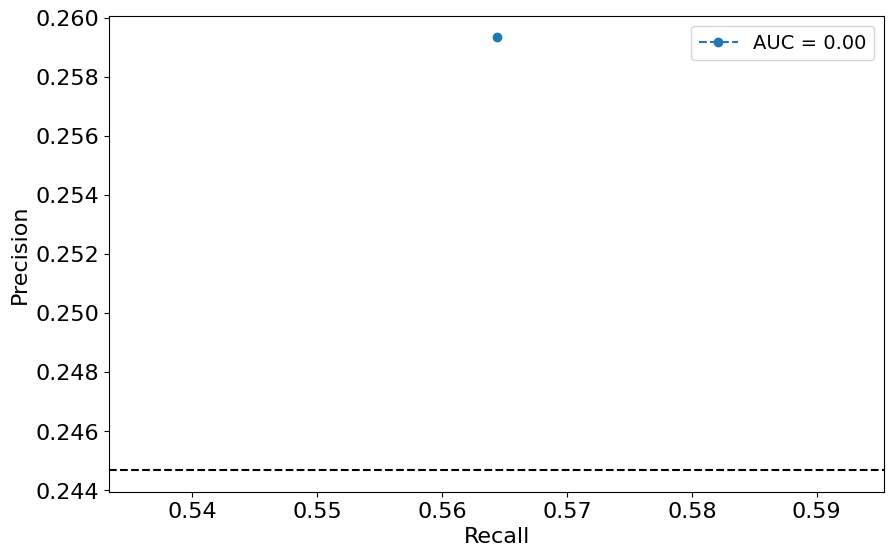

In [39]:
plt.plot(recall[precision<1], precision[precision<1], 'o--', label = f'AUC = {auc_pr:.2f}')
plt.axhline(y=baseline, c='k', ls='--')
plt.legend()
plt.xlabel('Recall')
plt.ylabel('Precision')

Text(0.5, 0, 'median $cos(\\theta)$')

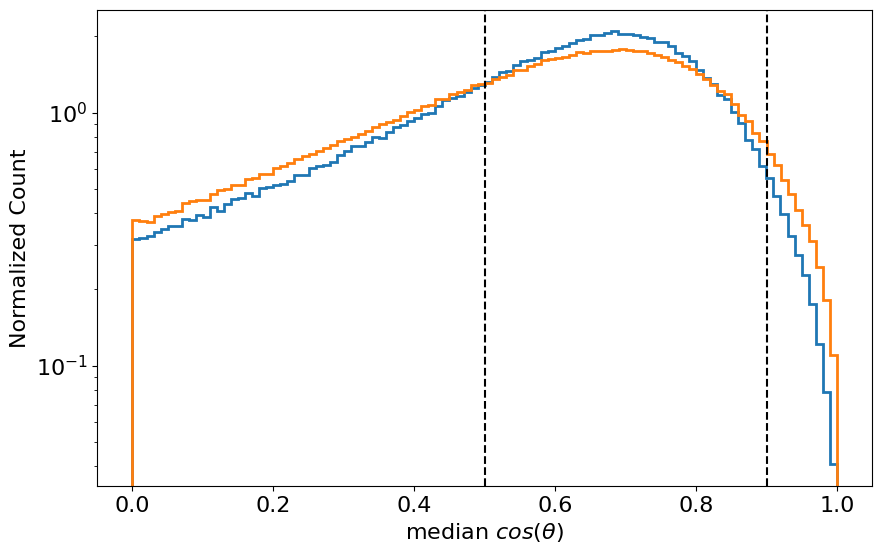

In [42]:
plt.hist(beta1[boolCC][(beta1 > 0) & (beta1 < 1)], bins=100, histtype='step', density=True, log=True, lw=2)
plt.hist(beta1[boolNC][(beta1 > 0) & (beta1 < 1)], bins=100
         , histtype='step', density=True, log=True, lw=2)
plt.axvline(x=lthreshold, c='k', ls='--')
plt.axvline(x=uthreshold, c='k', ls='--')
plt.ylabel('Normalized Count')
plt.xlabel(r'median $cos(\theta)$')

Text(0.5, 0, '$\\beta_1$')

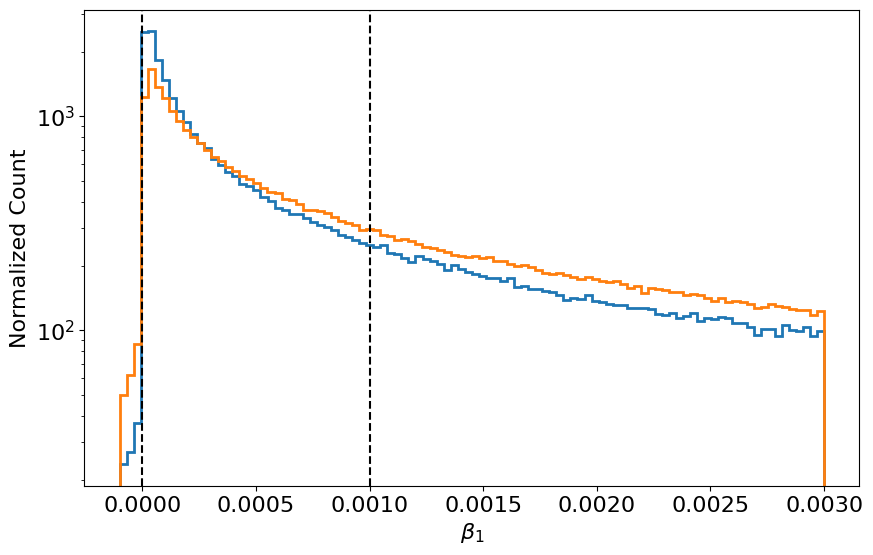

In [21]:
plt.hist(beta1[boolCC][(beta1 > -0.0001) & (beta1 < 0.003)], bins=100, histtype='step', density=True, log=True, lw=2)
plt.hist(beta1[boolNC][(beta1 > -0.0001) & (beta1 < 0.003)], bins=100, histtype='step', density=True, log=True, lw=2)
plt.axvline(x=lthreshold, c='k', ls='--')
plt.axvline(x=uthreshold, c='k', ls='--')
plt.ylabel('Normalized Count')
plt.xlabel(r'$\beta_1$')

In [ ]:
beta_threshold = np.arange(min(beta1), max(beta1)+0.1, 0.1) #np.arange(min(beta1), max(beta1)+0.00035, 0.00035)
beta_window = np.arange(min(beta1), max(beta1)+0.01, 0.01)
print(len(beta_threshold))

In [ ]:
len(beta_window)*len(beta_window)

In [ ]:
fpr = []
tpr = []

y_true = label
y_prob = beta1

count = 0
for uthreshold in beta_window: #beta_threshold:
    for lthreshold in beta_window:
        if uthreshold <= lthreshold:
            continue

        #if count % 100 == 0:
            #print(count)
        count += 1
    
        #y_pred = np.where((y_prob <= threshold), 1, 0)
        y_pred = np.where((y_prob <= uthreshold)&(y_prob >= lthreshold), 1, 0)
                          
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tp = np.sum((y_pred == 1) & (y_true == 1))
    
        fn = np.sum((y_pred == 0) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))
    
        fpr.append(fp / (fp + tn))
        tpr.append(tp / (tp + fn))


fpr = np.array(fpr)
tpr = np.array(tpr)

# Sort by FPR in case they're not
sorted_indices = np.argsort(fpr)
fpr = fpr[sorted_indices]
tpr = tpr[sorted_indices]

# Compute AUC using trapezoidal rule
auc = np.trapz(tpr, fpr)
print(f"AUC = {auc:.2f}")

In [ ]:
precision = []
recall = []

y_true = label
y_prob = beta1

count = 0
for uthreshold in beta_window: #beta_threshold:
    for lthreshold in beta_window:
        if uthreshold <= lthreshold:
            continue

        #if count % 100 == 0:
            #print(count)
        count += 1
    
        #y_pred = np.where((y_prob <= threshold), 1, 0)
        y_pred = np.where((y_prob <= uthreshold)&(y_prob >= lthreshold), 1, 0)
                          
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tp = np.sum((y_pred == 1) & (y_true == 1))
    
        fn = np.sum((y_pred == 0) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))
    
        precision.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)
        recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)

baseline = len(beta1_CC)/(len(beta1_CC) + len(beta1_NC))
print(baseline)

precision = np.array(precision)
recall = np.array(recall)

# Sort by FPR in case they're not
sorted_indices = np.argsort(recall)
precision = precision[sorted_indices]
recall = recall[sorted_indices]

# Compute AUC using trapezoidal rule
auc_pr = np.trapz(precision, recall)
print(f"AUC = {auc:.2f}")